In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

In [12]:
df = pd.read_csv("../dados/processados/dados_tratados.csv")
df.shape

(17182, 8)

In [13]:
df["Employment"].value_counts()

Employment
Employed, full-time    17182
Name: count, dtype: int64

In [14]:
df = df.drop(columns=["Employment"])
df.shape

(17182, 7)

In [15]:
df["Country"].value_counts().head(15)

Country
United States of America                                3788
Germany                                                 1486
United Kingdom of Great Britain and Northern Ireland    1125
Ukraine                                                  956
India                                                    823
France                                                   715
Canada                                                   677
Brazil                                                   454
Spain                                                    426
Italy                                                    412
Netherlands                                              405
Australia                                                396
Sweden                                                   369
Poland                                                   319
Switzerland                                              265
Name: count, dtype: int64

In [16]:
top_paises = df["Country"].value_counts().head(15).index
df["Country"] = df["Country"].apply(lambda x: x if x in top_paises else "Outro")
df["Country"].value_counts()

Country
Outro                                                   4566
United States of America                                3788
Germany                                                 1486
United Kingdom of Great Britain and Northern Ireland    1125
Ukraine                                                  956
India                                                    823
France                                                   715
Canada                                                   677
Brazil                                                   454
Spain                                                    426
Italy                                                    412
Netherlands                                              405
Australia                                                396
Sweden                                                   369
Poland                                                   319
Switzerland                                              265
Name: count, dty

In [17]:
colunas_categoricas = ["Country", "DevType", "EdLevel", "RemoteWork", "OrgSize"]

df_modelo = pd.get_dummies(df, columns=colunas_categoricas, drop_first=True)
df_modelo.shape

(17182, 70)

In [18]:
y = df_modelo["ConvertedCompYearly"]
X = df_modelo.drop(columns=["ConvertedCompYearly"])

In [19]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_treino.shape, X_teste.shape)

(13745, 69) (3437, 69)


In [20]:
modelo_linear = LinearRegression()
modelo_linear.fit(X_treino, y_treino)

previsoes_linear = modelo_linear.predict(X_teste)

mae_linear = mean_absolute_error(y_teste, previsoes_linear)
rmse_linear = np.sqrt(mean_squared_error(y_teste, previsoes_linear))

print(f"MAE: {mae_linear:.2f}")
print(f"RMSE: {rmse_linear:.2f}")

MAE: 28981.59
RMSE: 42549.79


In [21]:
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_treino, y_treino)

previsoes_rf = modelo_rf.predict(X_teste)

mae_rf = mean_absolute_error(y_teste, previsoes_rf)
rmse_rf = np.sqrt(mean_squared_error(y_teste, previsoes_rf))

print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")

MAE: 30125.79
RMSE: 45031.14


In [22]:
modelo_gb = GradientBoostingRegressor(random_state=42)
modelo_gb.fit(X_treino, y_treino)

previsoes_gb = modelo_gb.predict(X_teste)

mae_gb = mean_absolute_error(y_teste, previsoes_gb)
rmse_gb = np.sqrt(mean_squared_error(y_teste, previsoes_gb))

print(f"MAE: {mae_gb:.2f}")
print(f"RMSE: {rmse_gb:.2f}")

MAE: 28544.25
RMSE: 42322.54


In [23]:
resultados = pd.DataFrame({
    "Modelo": ["Regressão Linear", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_linear, mae_rf, mae_gb],
    "RMSE": [rmse_linear, rmse_rf, rmse_gb]
})

resultados

,Modelo,MAE,RMSE
0,Regressão Linear,28981.592060,42549.788002
1,Random Forest,30125.792803,45031.138023
2,Gradient Boosting,28544.253165,42322.541853


In [24]:
importancias = pd.DataFrame({
    "variavel": X.columns,
    "importancia": modelo_gb.feature_importances_
}).sort_values("importancia", ascending=False)

importancias.head(10)

,variavel,importancia
15,Country_United States of America,0.579758
0,YearsCodePro,0.203971
5,Country_India,0.023004
60,"OrgSize_10,000 or more employees",0.022624
13,Country_Ukraine,0.020135
12,Country_Switzerland,0.019166
14,Country_United Kingdom of Great Britain and No...,0.019031
2,Country_Canada,0.014751
8,Country_Outro,0.013241
1,Country_Brazil,0.011306


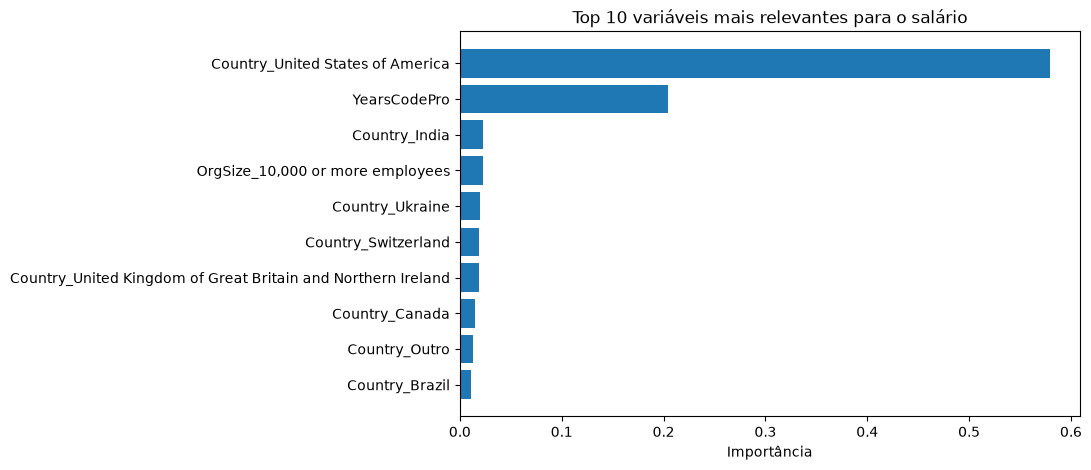

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.barh(importancias["variavel"].head(10), importancias["importancia"].head(10))
plt.xlabel("Importância")
plt.title("Top 10 variáveis mais relevantes para o salário")
plt.gca().invert_yaxis()
plt.show()

In [26]:
joblib.dump(modelo_gb, "../modelos/modelo_salario.pkl")
joblib.dump(X.columns.tolist(), "../modelos/colunas_modelo.pkl")

['../modelos/colunas_modelo.pkl']

In [27]:
colunas_pais = [col for col in X.columns if col.startswith("Country_")]
colunas_pais

['Country_Brazil',
 'Country_Canada',
 'Country_France',
 'Country_Germany',
 'Country_India',
 'Country_Italy',
 'Country_Netherlands',
 'Country_Outro',
 'Country_Poland',
 'Country_Spain',
 'Country_Sweden',
 'Country_Switzerland',
 'Country_Ukraine',
 'Country_United Kingdom of Great Britain and Northern Ireland',
 'Country_United States of America']

In [28]:
X_sem_pais = X.drop(columns=colunas_pais)
X_sem_pais.shape

(17182, 54)

In [29]:
X_treino_sp, X_teste_sp, y_treino_sp, y_teste_sp = train_test_split(
    X_sem_pais, y, test_size=0.2, random_state=42
)

In [30]:
modelo_gb_sem_pais = GradientBoostingRegressor(random_state=42)
modelo_gb_sem_pais.fit(X_treino_sp, y_treino_sp)

previsoes_sem_pais = modelo_gb_sem_pais.predict(X_teste_sp)

mae_sem_pais = mean_absolute_error(y_teste_sp, previsoes_sem_pais)
rmse_sem_pais = np.sqrt(mean_squared_error(y_teste_sp, previsoes_sem_pais))

print(f"MAE sem país: {mae_sem_pais:.2f}")
print(f"RMSE sem país: {rmse_sem_pais:.2f}")

MAE sem país: 40372.03
RMSE sem país: 55572.85


In [31]:
comparacao_pais = pd.DataFrame({
    "Cenário": ["Com país", "Sem país"],
    "MAE": [mae_gb, mae_sem_pais],
    "RMSE": [rmse_gb, rmse_sem_pais]
})

comparacao_pais["Piora no MAE (%)"] = (
    (comparacao_pais["MAE"] - mae_gb) / mae_gb * 100
)

comparacao_pais

,Cenário,MAE,RMSE,Piora no MAE (%)
0,Com país,28544.253165,42322.541853,0.000000
1,Sem país,40372.031249,55572.850838,41.436635
